In [6]:
import glob
import io
import os

import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from emle.models import EMLEAEVComputer
from IPython.display import Image
from PIL import Image
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import rdMolDraw2D
from scipy.io import loadmat
from scipy.spatial.distance import cdist

sns.set_style("whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "font.size": 12,
    }
)

## 2. Paths and File Discovery

In [7]:
sdf_folder = "../../datasets/SAMPL5/SDFs"
model_path = "../../emle_models/ligand_patched_static_only.mat"

target_molecules = [
    "SAMPL5_019",
    "SAMPL5_020",
    "SAMPL5_021",
    "SAMPL5_046",
    "SAMPL5_058",
    "SAMPL5_068",
    "SAMPL5_071",
    "SAMPL5_080",
    "SAMPL5_090",
]

all_sdf = sorted(glob.glob(os.path.join(sdf_folder, "*.sdf")))
sdf_files = [
    f for f in all_sdf if os.path.splitext(os.path.basename(f))[0] in target_molecules
]

for f in sdf_files:
    print(f"{os.path.basename(f)}")

SAMPL5_019.sdf
SAMPL5_020.sdf
SAMPL5_021.sdf
SAMPL5_046.sdf
SAMPL5_058.sdf
SAMPL5_068.sdf
SAMPL5_071.sdf
SAMPL5_080.sdf
SAMPL5_090.sdf


## Load Reference Model and Initialise AEV Computer

In [8]:
mat_data = loadmat(model_path, squeeze_me=True)

reference_aevs = mat_data["ref_aev"]
if reference_aevs.ndim == 3:
    reference_aevs = reference_aevs.reshape(-1, reference_aevs.shape[-1])
print(f"Reference AEVs: {reference_aevs.shape}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32
aev_mask = torch.tensor(mat_data["aev_mask"], dtype=torch.bool, device=device)
num_species = int(mat_data.get("computer_n_species", 7))

aev_computer = EMLEAEVComputer(
    mask=aev_mask, num_species=num_species, device=device, dtype=dtype
)

species_map = {1: 0, 6: 1, 7: 2, 8: 3, 16: 4, 9: 5, 17: 6}

print(f"Device: {device}  |  AEV dim: {reference_aevs.shape[1]}")

Reference AEVs: (515, 432)
Device: cuda  |  AEV dim: 432


## 4. Compute Outliers for Every Molecule

In [9]:
records = []

for sdf_path in sdf_files:
    mol_name = os.path.basename(sdf_path).replace(".sdf", "")

    suppl = Chem.SDMolSupplier(sdf_path, removeHs=False)
    mol = next(suppl)
    if mol is None:
        print(f"Could not parse {mol_name}")
        continue

    conf = mol.GetConformer()
    positions = conf.GetPositions()
    atomic_numbers = [a.GetAtomicNum() for a in mol.GetAtoms()]
    n_atoms = len(atomic_numbers)

    zid = [species_map.get(z, 0) for z in atomic_numbers]
    zid_t = torch.tensor([zid], dtype=torch.long, device=device)
    coords_t = torch.tensor([positions], dtype=dtype, device=device)

    with torch.no_grad():
        aev = aev_computer(zid_t, coords_t)
    struct_aevs = aev.cpu().numpy().squeeze()
    if struct_aevs.ndim == 1:
        struct_aevs = struct_aevs[np.newaxis, :]

    dists = cdist(struct_aevs, reference_aevs, metric="euclidean")
    min_dists = dists.min(axis=1)

    mu, sigma = min_dists.mean(), min_dists.std()
    threshold = 0.85  # mu + 2.0 * sigma

    heavy_mask = np.array([z != 1 for z in atomic_numbers])
    outlier_indices = np.where(min_dists > threshold)[0]

    n_heavy = int(heavy_mask.sum())
    n_out = len(outlier_indices)

    if n_out > 0:
        z_scores = (min_dists[outlier_indices] - mu) / sigma
    else:
        z_scores = np.array([])

    records.append(
        {
            "molecule": mol_name,
            "mol": mol,
            "atomic_numbers": atomic_numbers,
            "n_atoms": n_atoms,
            "n_heavy": n_heavy,
            "min_dists": min_dists,
            "mu": mu,
            "sigma": sigma,
            "threshold": threshold,
            "outlier_indices": outlier_indices.tolist(),
            "outlier_zscores": z_scores.tolist(),
            "n_outliers": n_out,
        }
    )
    print(
        f"  {mol_name:15s}  n_atoms: {n_atoms:3d}  heavy: {n_heavy:3d}  outliers: {n_out}"
    )

df = pd.DataFrame(records)

  SAMPL5_019       n_atoms:  40  heavy:  22  outliers: 0
  SAMPL5_020       n_atoms:  36  heavy:  18  outliers: 1
  SAMPL5_021       n_atoms:  28  heavy:  17  outliers: 2
  SAMPL5_046       n_atoms:  34  heavy:  21  outliers: 1
  SAMPL5_058       n_atoms:  27  heavy:  17  outliers: 1
  SAMPL5_068       n_atoms:  38  heavy:  24  outliers: 6
  SAMPL5_071       n_atoms:  41  heavy:  19  outliers: 0
  SAMPL5_080       n_atoms:  24  heavy:  14  outliers: 3
  SAMPL5_090       n_atoms:  40  heavy:  24  outliers: 4


## Grid

/tmp/ipykernel_1598410/3329461267.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Wistia")


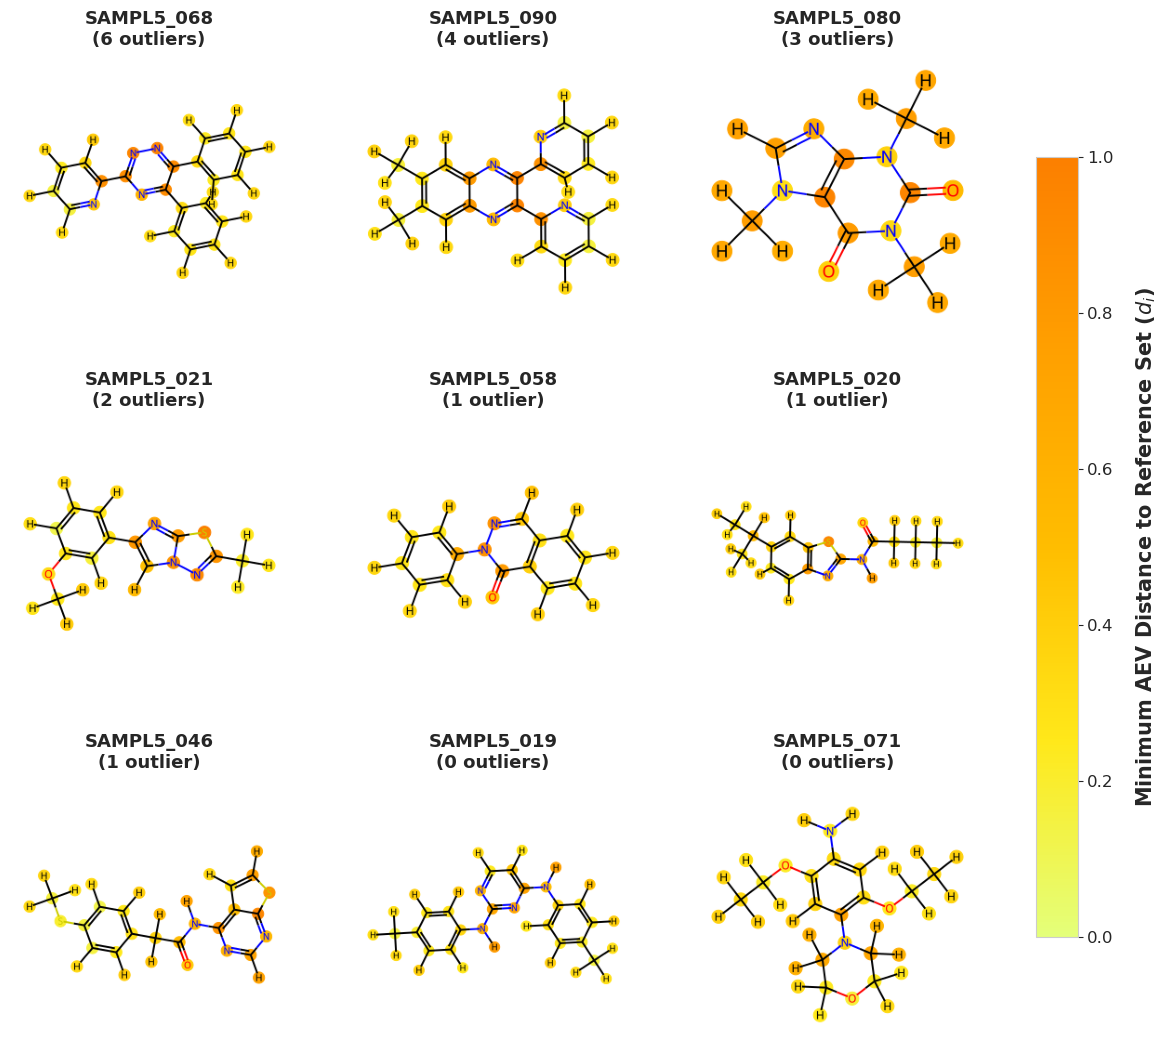

In [10]:
sorted_df = df.sort_values("n_outliers", ascending=False)

fig, axes = plt.subplots(3, 3, figsize=(14, 13))
axes = axes.flatten()

all_dists = np.concatenate(df["min_dists"].values)
max_dist = all_dists.max()
vmin = 0.0
vmax = float(np.ceil(max_dist * 10) / 10)

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = cm.get_cmap("Wistia")

for idx, (_, row) in enumerate(sorted_df.iterrows()):
    mol = row["mol"]
    min_dists = row["min_dists"]
    mol_name = row["molecule"]
    n_out = row["n_outliers"]

    highlight_atoms = list(range(mol.GetNumAtoms()))
    highlight_colors = {}
    highlight_radii = {}
    for aid in range(mol.GetNumAtoms()):
        d = min_dists[aid]
        highlight_colors[aid] = cmap(norm(d))[:3]
        highlight_radii[aid] = 0.35

    mol_2d = Chem.RWMol(mol)
    AllChem.Compute2DCoords(mol_2d)

    drawer = rdMolDraw2D.MolDraw2DCairo(300, 300)
    drawer.drawOptions().backgroundColour = (1, 1, 1, 1)
    drawer.drawOptions().addAtomIndices = False
    drawer.drawOptions().explicitMethyl = True
    drawer.drawOptions().legendFraction = 0.0
    drawer.drawOptions().padding = 0.05

    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer,
        mol_2d,
        highlightAtoms=highlight_atoms,
        highlightAtomColors=highlight_colors,
        highlightAtomRadii=highlight_radii,
    )
    drawer.FinishDrawing()
    png_bytes = drawer.GetDrawingText()

    img = Image.open(io.BytesIO(png_bytes))
    ax = axes[idx]
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(
        f"{mol_name}\n({n_out} outlier{'s' if n_out != 1 else ''})",
        fontsize=13,
        fontweight="bold",
    )

fig.subplots_adjust(right=0.84, wspace=0.1, hspace=0.3)
cbar_ax = fig.add_axes([0.87, 0.2, 0.03, 0.6])
cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax)
cb.set_label(
    "Minimum AEV Distance to Reference Set ($d_i$)",
    fontsize=15,
    fontweight="bold",
    labelpad=15,
)
cb.ax.tick_params(labelsize=12)

plt.savefig("SAMPL5_atom_outliers_grid.pdf", dpi=300, bbox_inches="tight")
plt.show()